In [179]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split

In [180]:
df = pd.read_csv('heart.csv')

In [181]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [182]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


## there is no null values

## data dictionary (taken from lecture notes)
- age: age of the patient
- sex: gender of the patient
- cp: chest pain type
- trestbps: resting blood pressure
- chol: cholesterol level
- fbs: fasting blood sugar
- restecg: Resting electrocardiographic results
- thalach: Maximum heart rate achieved during a stress test 
- exang: Exercise-induced angina 
- oldpeak: ST depression induced by exercise relative to rest 
- slope: Slope of the peak exercise ST segment
- ca: Number of major vessels (0-4) colored by fluoroscopy          
- thal: Thalium stress test result
- target: Heart disease status (0 = no disease, 1 = presence of disease) 

In [183]:
df.shape

(303, 14)

In [184]:
df.target.value_counts()

target
1    165
0    138
Name: count, dtype: int64

## the data is balanced

In [185]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

In [186]:
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

In [187]:
set(df.columns) - set(continuous_features)

{'ca', 'cp', 'exang', 'fbs', 'restecg', 'sex', 'slope', 'target', 'thal'}

In [188]:
categorical_features = list(set(df.columns) - set(continuous_features))
categorical_features

['restecg', 'sex', 'exang', 'cp', 'slope', 'target', 'thal', 'fbs', 'ca']

In [189]:
df[categorical_features] = df[categorical_features].astype('O')

In [190]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    object 
 2   cp        303 non-null    object 
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    object 
 6   restecg   303 non-null    object 
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    object 
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    object 
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    object 
dtypes: float64(1), int64(4), object(9)
memory usage: 33.3+ KB


# EDA

In [191]:
len(continuous_features)

5

Text(0.5, 1.0, 'Continuous Features Distribution')

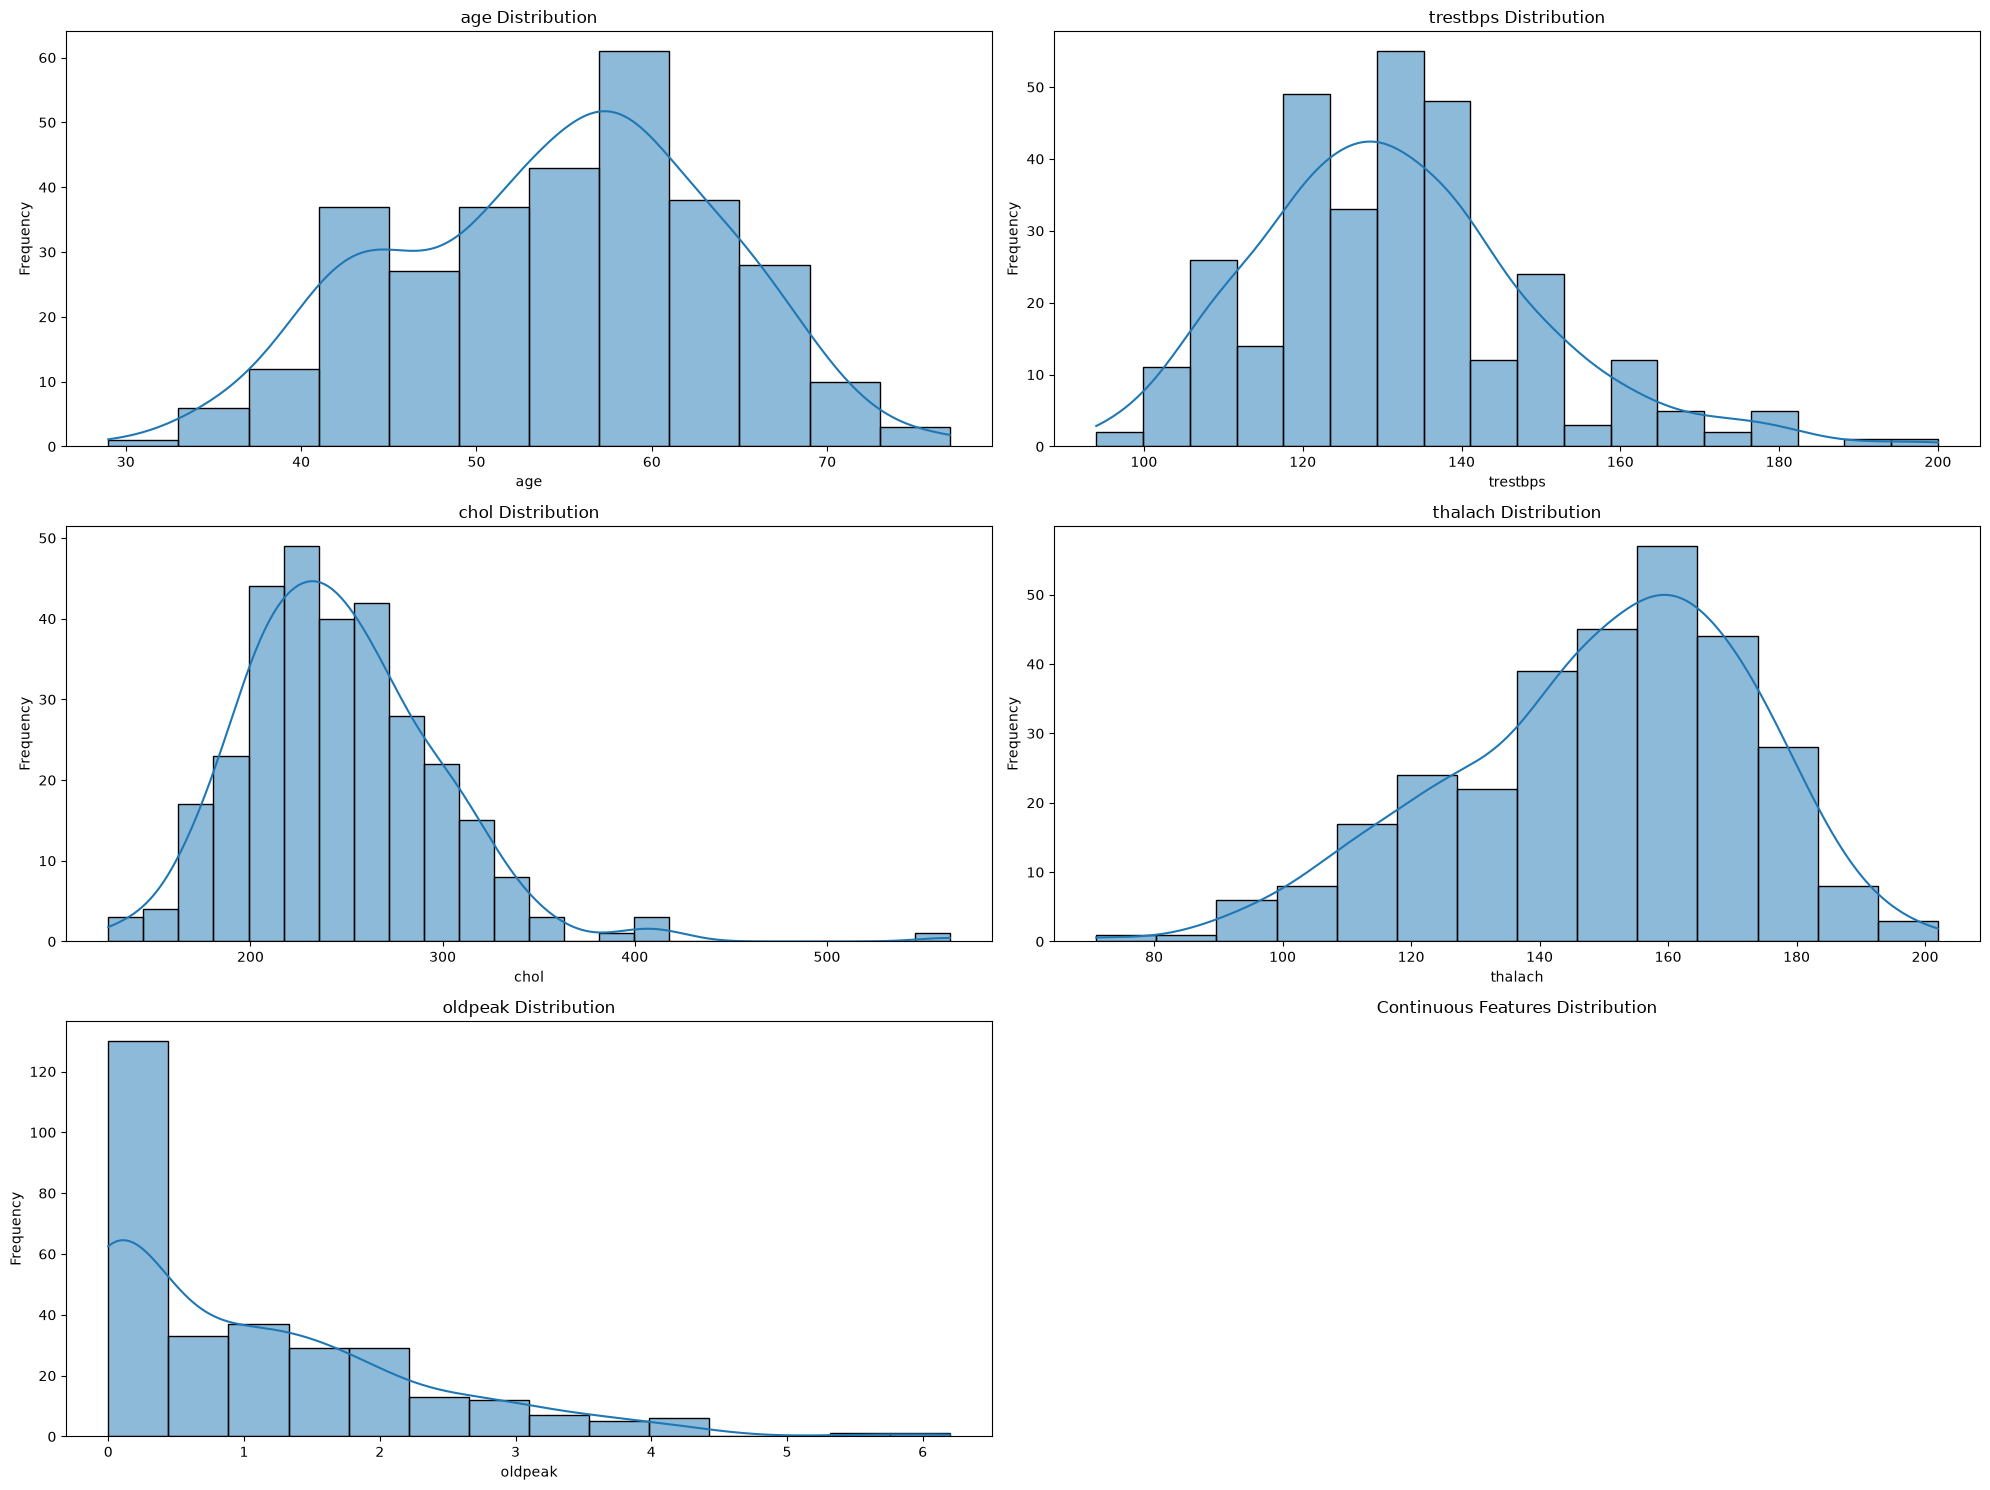

In [192]:
fig, ax = plt.subplots(ncols=2, nrows=len(continuous_features)//2+1, figsize=(20, 15))
for i, feature in enumerate(continuous_features):
    sns.histplot(data=df, x=feature, kde=True, ax=ax[i//2, i%2])
    ax[i//2, i%2].set_title(f'{feature} Distribution')
    ax[i//2, i%2].set_xlabel(feature)
    ax[i//2, i%2].set_ylabel('Frequency')

ax[2,1].axis('off')
plt.tight_layout()
plt.title('Continuous Features Distribution')

### the oldpeak distribution is right skewed

Text(0.5, 1.0, 'Categorical Features Distribution')

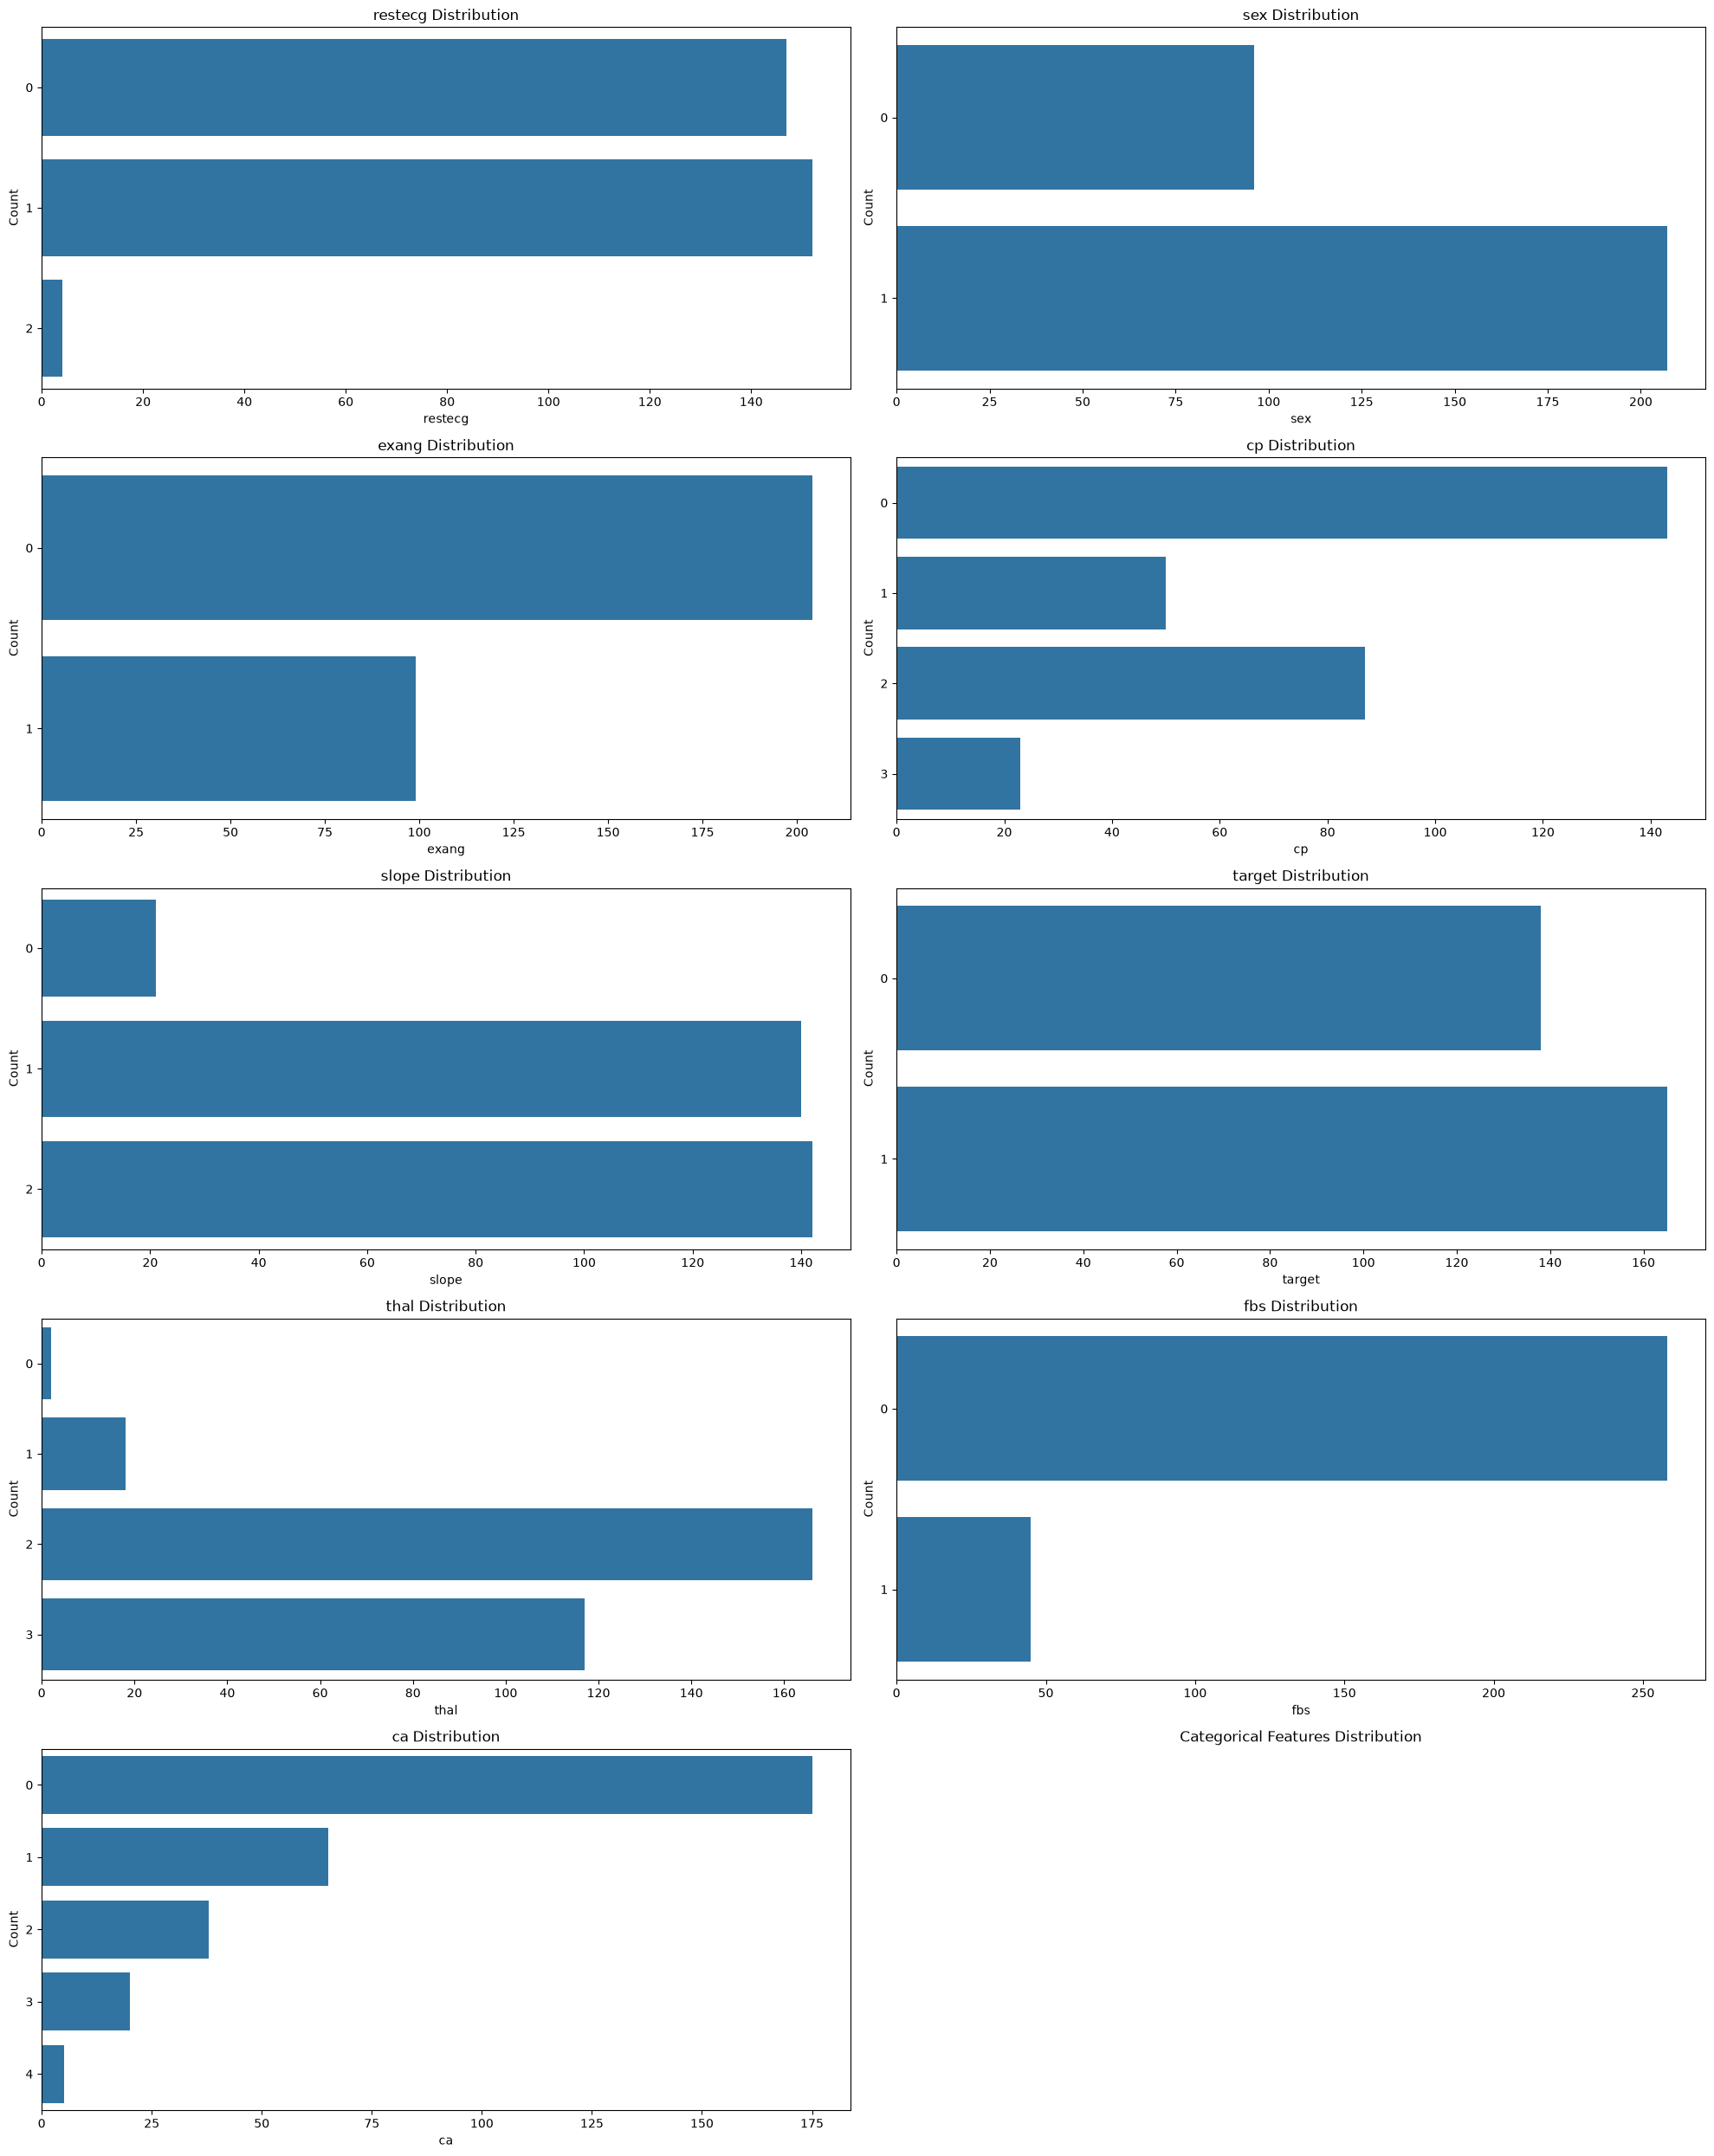

In [193]:
fig, ax = plt.subplots(ncols=2, nrows=len(categorical_features)//2+1, figsize=(20, 25))
for i, feature in enumerate(categorical_features):
    sns.countplot(data=df,y =feature, ax=ax[i//2, i%2])
    ax[i//2, i%2].set_title(f'{feature} Distribution')
    ax[i//2, i%2].set_xlabel(feature)
    ax[i//2, i%2].set_ylabel('Count')
plt.tight_layout()
ax[4,1].axis('off')
plt.title('Categorical Features Distribution')

## conclusion
- resteg: The results show varied resting electrocardiographic outcomes, with certain types being more common than others. 
- sex: The dataset is predominantly female, constituting a significant majority.
- fbs: A significant majority of the patients have their fasting blood sugar level is 0, indicating that high blood sugar is not a common condition in this dataset.
- ca: Most patients have fewer major vessels colored by fluoroscopy, with '0' being the most frequent.

## correlation matrix

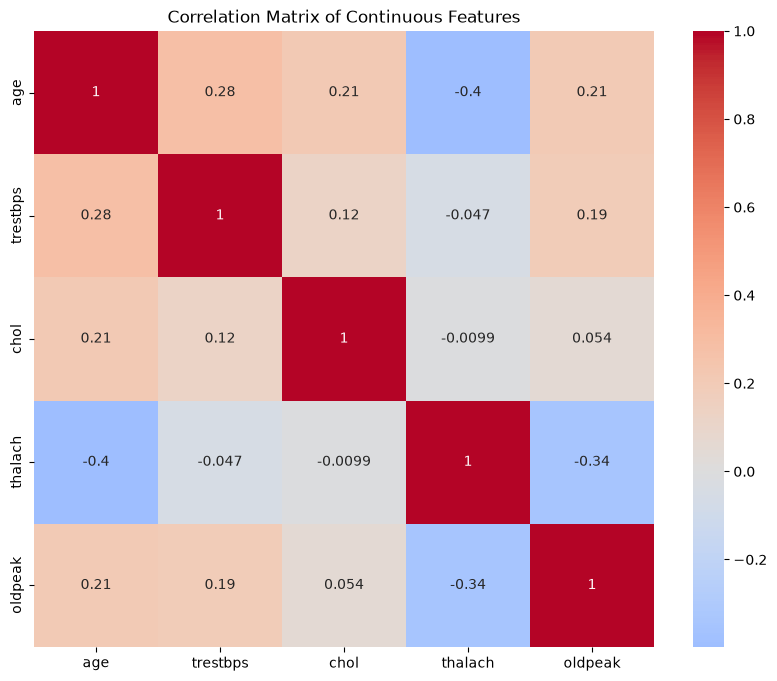

In [194]:
corr_matrix = df[continuous_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Continuous Features')
plt.show()



## we don't have any multicollinearity in the data

# feature engineering

In [195]:
# categorical features that need to be encoded
for feature in categorical_features:
    print(df[feature].nunique())

3
2
2
4
3
2
4
2
5


In [196]:
encoded_features = [feature for feature in categorical_features if df[feature].nunique() > 2]
print(encoded_features)
features_to_convert = [feature for feature in categorical_features if df[feature].nunique() <= 2]
print(features_to_convert)


['restecg', 'cp', 'slope', 'thal', 'ca']
['sex', 'exang', 'target', 'fbs']


In [197]:
# one hot encoding
df = pd.get_dummies(df, columns=encoded_features, drop_first=True)
df.head()
# feature convert
for feature in features_to_convert:
    df[feature] = df[feature].astype('int')
df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,target,restecg_1,...,cp_3,slope_1,slope_2,thal_1,thal_2,thal_3,ca_1,ca_2,ca_3,ca_4
0,63,1,145,233,1,150,0,2.3,1,False,...,True,False,False,True,False,False,False,False,False,False
1,37,1,130,250,0,187,0,3.5,1,True,...,False,False,False,False,True,False,False,False,False,False
2,41,0,130,204,0,172,0,1.4,1,False,...,False,False,True,False,True,False,False,False,False,False
3,56,1,120,236,0,178,0,0.8,1,True,...,False,False,True,False,True,False,False,False,False,False
4,57,0,120,354,0,163,1,0.6,1,True,...,False,False,True,False,True,False,False,False,False,False


In [198]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 23 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        303 non-null    int64  
 1   sex        303 non-null    int64  
 2   trestbps   303 non-null    int64  
 3   chol       303 non-null    int64  
 4   fbs        303 non-null    int64  
 5   thalach    303 non-null    int64  
 6   exang      303 non-null    int64  
 7   oldpeak    303 non-null    float64
 8   target     303 non-null    int64  
 9   restecg_1  303 non-null    bool   
 10  restecg_2  303 non-null    bool   
 11  cp_1       303 non-null    bool   
 12  cp_2       303 non-null    bool   
 13  cp_3       303 non-null    bool   
 14  slope_1    303 non-null    bool   
 15  slope_2    303 non-null    bool   
 16  thal_1     303 non-null    bool   
 17  thal_2     303 non-null    bool   
 18  thal_3     303 non-null    bool   
 19  ca_1       303 non-null    bool   
 20  ca_2       303 non-nu

In [199]:
# get dummies is returing bool cols
bool_cols = [col for col in df.columns if df[col].dtype == 'bool']
print(bool_cols)
# drop bool cols
df[bool_cols] = df[bool_cols].astype(int)
df.info()

['restecg_1', 'restecg_2', 'cp_1', 'cp_2', 'cp_3', 'slope_1', 'slope_2', 'thal_1', 'thal_2', 'thal_3', 'ca_1', 'ca_2', 'ca_3', 'ca_4']
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 23 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        303 non-null    int64  
 1   sex        303 non-null    int64  
 2   trestbps   303 non-null    int64  
 3   chol       303 non-null    int64  
 4   fbs        303 non-null    int64  
 5   thalach    303 non-null    int64  
 6   exang      303 non-null    int64  
 7   oldpeak    303 non-null    float64
 8   target     303 non-null    int64  
 9   restecg_1  303 non-null    int64  
 10  restecg_2  303 non-null    int64  
 11  cp_1       303 non-null    int64  
 12  cp_2       303 non-null    int64  
 13  cp_3       303 non-null    int64  
 14  slope_1    303 non-null    int64  
 15  slope_2    303 non-null    int64  
 16  thal_1     303 non-null    int64  
 17  thal_2

In [200]:
# split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(df.drop('target', axis=1), df['target'], test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(242, 22) (61, 22) (242,) (61,)


In [201]:
# oldpeak is skewed so applying boxcox transformation
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='box-cox')

In [202]:
X_train['oldpeak'] = X_train['oldpeak'].apply(lambda x: x - df['oldpeak'].min() + 1e-6 if x <= 0 else x)
X_train.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,restecg_1,restecg_2,...,cp_3,slope_1,slope_2,thal_1,thal_2,thal_3,ca_1,ca_2,ca_3,ca_4
132,42,1,120,295,0,162,0,0.000001,1,0,...,0,0,1,0,1,0,0,0,0,0
202,58,1,150,270,0,111,1,0.800000,0,0,...,0,0,1,0,0,1,0,0,0,0
196,46,1,150,231,0,147,0,3.600000,1,0,...,0,1,0,0,1,0,0,0,0,0
75,55,0,135,250,0,161,0,1.400000,0,0,...,0,1,0,0,1,0,0,0,0,0
176,60,1,117,230,1,160,1,1.400000,1,0,...,0,0,1,0,0,1,0,1,0,0


In [203]:
X_train['oldpeak'] = pt.fit_transform(X_train[['oldpeak']])
X_train.head()   


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,restecg_1,restecg_2,...,cp_3,slope_1,slope_2,thal_1,thal_2,thal_3,ca_1,ca_2,ca_3,ca_4
132,42,1,120,295,0,162,0,-1.410995,1,0,...,0,0,1,0,1,0,0,0,0,0
202,58,1,150,270,0,111,1,0.544496,0,0,...,0,0,1,0,0,1,0,0,0,0
196,46,1,150,231,0,147,0,1.085081,1,0,...,0,1,0,0,1,0,0,0,0,0
75,55,0,135,250,0,161,0,0.732403,0,0,...,0,1,0,0,1,0,0,0,0,0
176,60,1,117,230,1,160,1,0.732403,1,0,...,0,0,1,0,0,1,0,1,0,0


Text(0.5, 1.0, 'Continuous Features Distribution')

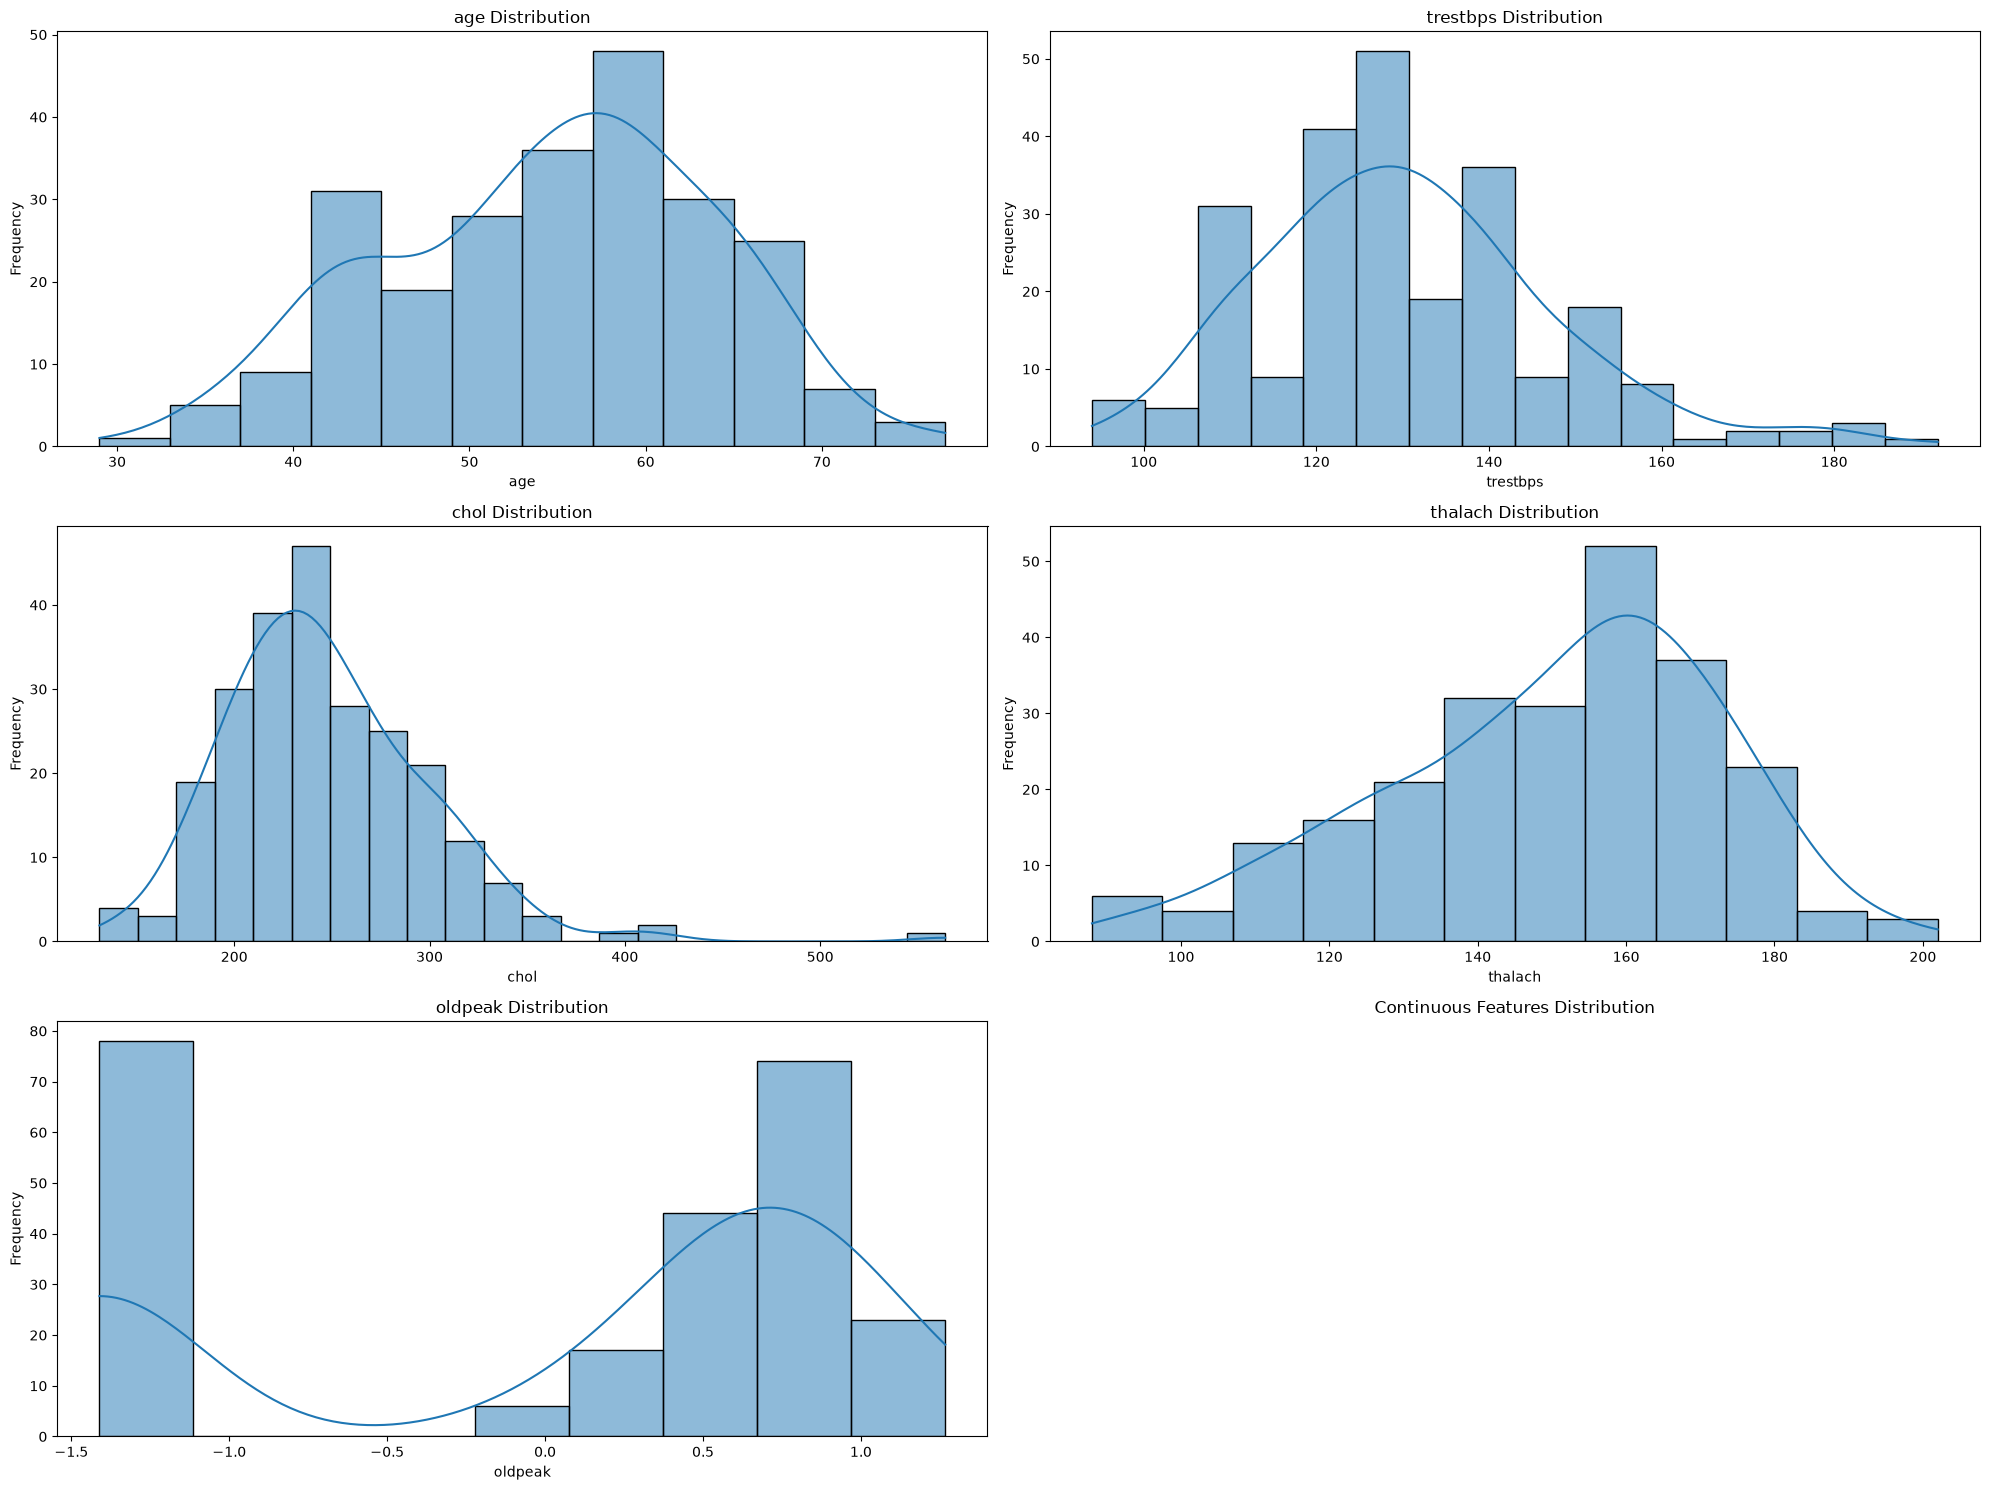

In [204]:
fig, ax = plt.subplots(ncols=2, nrows=len(continuous_features)//2+1, figsize=(20, 15))
for i, feature in enumerate(continuous_features):
    sns.histplot(data=X_train, x=feature, kde=True, ax=ax[i//2, i%2])
    ax[i//2, i%2].set_title(f'{feature} Distribution')
    ax[i//2, i%2].set_xlabel(feature)
    ax[i//2, i%2].set_ylabel('Frequency')

ax[2,1].axis('off')
plt.tight_layout()
plt.title('Continuous Features Distribution')

In [205]:
X_test['oldpeak'] = X_test['oldpeak'].apply(lambda x: x - df['oldpeak'].min() + 1e-6 if x <= 0 else x)
X_test.head()
X_test['oldpeak'] = pt.transform(X_test[['oldpeak']])
X_test.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,restecg_1,restecg_2,...,cp_3,slope_1,slope_2,thal_1,thal_2,thal_3,ca_1,ca_2,ca_3,ca_4
179,57,1,150,276,0,112,1,0.453503,0,0,...,0,1,0,1,0,0,1,0,0,0
228,59,1,170,288,0,159,0,0.138001,0,0,...,1,1,0,0,0,1,0,0,0,0
111,57,1,150,126,1,173,0,0.138001,1,0,...,0,0,1,0,0,1,1,0,0,0
246,56,0,134,409,0,150,1,0.841354,0,0,...,0,1,0,0,0,1,0,1,0,0
60,71,0,110,265,1,130,0,-1.410995,0,0,...,0,0,1,0,1,0,1,0,0,0


In [206]:
# feature scalling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train[continuous_features] = scaler.fit_transform(X_train[continuous_features])
X_test[continuous_features] = scaler.transform(X_test[continuous_features])
X_train = pd.DataFrame(X_train, columns=X_train.columns)
X_test = pd.DataFrame(X_test, columns=X_test.columns)
X_train.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,restecg_1,restecg_2,...,cp_3,slope_1,slope_2,thal_1,thal_2,thal_3,ca_1,ca_2,ca_3,ca_4
132,-1.356798,1,-0.616856,0.914034,0,0.532781,0,-1.410995,1,0,...,0,0,1,0,1,0,0,0,0,0
202,0.385086,1,1.169491,0.439527,0,-1.753582,1,0.544496,0,0,...,0,0,1,0,0,1,0,0,0,0
196,-0.921327,1,1.169491,-0.300704,0,-0.139679,0,1.085081,1,0,...,0,1,0,0,1,0,0,0,0,0
75,0.058483,0,0.276318,0.059921,0,0.487950,0,0.732403,0,0,...,0,1,0,0,1,0,0,0,0,0
176,0.602822,1,-0.795490,-0.319684,1,0.443119,1,0.732403,1,0,...,0,0,1,0,0,1,0,1,0,0


# Baseline model

In [207]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import f1_score, recall_score, precision_score

In [208]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.93      0.86        29
           1       0.93      0.78      0.85        32

    accuracy                           0.85        61
   macro avg       0.86      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61

[[27  2]
 [ 7 25]]
0.8524590163934426


In [209]:
# we need to improve the model recall for class 1 as it is more important to predict the disease
# so we will use class weight to balance the class
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.97      0.86        29
           1       0.96      0.75      0.84        32

    accuracy                           0.85        61
   macro avg       0.87      0.86      0.85        61
weighted avg       0.87      0.85      0.85        61

[[28  1]
 [ 8 24]]


In [210]:
# recall didn't improve much so we will try other models
# trying other models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

In [211]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.79      0.90      0.84        29
           1       0.89      0.78      0.83        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61

[[26  3]
 [ 7 25]]
0.8360655737704918


In [212]:
svc = SVC(kernel='linear', class_weight='balanced')
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.78      0.97      0.86        29
           1       0.96      0.75      0.84        32

    accuracy                           0.85        61
   macro avg       0.87      0.86      0.85        61
weighted avg       0.87      0.85      0.85        61

[[28  1]
 [ 8 24]]
0.8524590163934426


In [213]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.75      0.83      0.79        29
           1       0.83      0.75      0.79        32

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61

[[24  5]
 [ 8 24]]
0.7868852459016393


In [214]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.86      0.86      0.86        29
           1       0.88      0.88      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61

[[25  4]
 [ 4 28]]
0.8688524590163934


In [215]:
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.86      0.83        29
           1       0.87      0.81      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61

[[25  4]
 [ 6 26]]
0.8360655737704918


# we can see that the xgb model is performing better than the other models
- so we will use xgb model for the final model
- we will use grid search to find the best parameters for the xgb model
- we will use the best parameters to train the xgb model

In [216]:
# parameters to tune
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 1],
    'max_depth': [3, 4, 5, 7], 
    'subsample': [0.5, 0.7, 1],
    'colsample_bytree': [0.5, 0.7, 1],
    'gamma': [0, 0.1, 0.2]
}
# grid search
grid_search = GridSearchCV(
    estimator=xgb, 
    param_grid=param_grid, 
    cv=5,
    scoring='recall', 
    verbose=3,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)

Fitting 5 folds for each of 972 candidates, totalling 4860 fits
[CV 3/5] END colsample_bytree=0.5, gamma=0, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.5;, score=0.889 total time=   0.0s
[CV 5/5] END colsample_bytree=0.5, gamma=0, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.5;, score=0.846 total time=   0.0s
[CV 1/5] END colsample_bytree=0.5, gamma=0, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.5;, score=0.926 total time=   0.0s
[CV 4/5] END colsample_bytree=0.5, gamma=0, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.5;, score=0.923 total time=   0.0s
[CV 2/5] END colsample_bytree=0.5, gamma=0, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.5;, score=0.852 total time=   0.1s
[CV 2/5] END colsample_bytree=0.5, gamma=0, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.7;, score=0.852 total time=   0.1s
[CV 1/5] END colsample_bytree=0.5, gamma=0, learning_rate=0.01, max_depth=3, n_estim

In [217]:
best_xgb = grid_search.best_estimator_   # already fitted on full X_train
y_pred = best_xgb.predict(X_test)

print("CV recall (best_score_):", round(grid_search.best_score_, 3))
print("Test recall (class 1):  ", round(recall_score(y_test, y_pred), 3))
print("Test accuracy:          ", round(accuracy_score(y_test, y_pred), 3))
print(classification_report(y_test, y_pred))

CV recall (best_score_): 0.894
Test recall (class 1):   0.812
Test accuracy:           0.836
              precision    recall  f1-score   support

           0       0.81      0.86      0.83        29
           1       0.87      0.81      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



# Summary

I worked on the heart disease dataset (303 patients). First cleaned / encoded the data, looked at distributions, then tried a few models. XGBoost was doing better so I tuned it with GridSearch (scoring=recall because missing a sick patient is worse).

Best params from CV gave about **0.89 recall** on the training folds. On the test set it was a bit lower: **accuracy ~0.84**, **disease recall ~0.81**. That gap is normal — CV is on train, test is unseen.

From EDA, things like oldpeak, chest pain type, vessels (ca), thalium result seemed related to disease. The model is decent for a small dataset but still misses some positive cases (6 false negatives in the confusion matrix), so it shouldn't be treated like a real medical diagnosis tool.

Overall: encoding + scaling helped, recall-focused tuning makes sense here, and XGB with the tuned params is what I'd keep as the final model for this assignment.
